[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/FranQuant/llm-regime-allocator/blob/main/notebooks/nb03_regimes_to_portfolios.ipynb)

In [1]:
# Colab setup: fetch the repo (data, results and the replayable LLM cache), work from its notebooks/ folder.
# Runs only on Colab; locally this cell does nothing. No API keys or paid calls are needed.
import os, subprocess, sys
if 'google.colab' in sys.modules and not os.path.exists('../src/lra'):
    repo = '/content/llm-regime-allocator'
    if not os.path.exists(repo):
        subprocess.run(['git', 'clone', '-q', '--depth', '1',
                        'https://github.com/FranQuant/llm-regime-allocator.git', repo], check=True)
    os.chdir(f'{repo}/notebooks')
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', 'pydantic>=2', 'scikit-learn'], check=True)

# nb03 — Does regime skill turn into better portfolios?

**Question.** nb02 found that Sonnet 5.5, reading the blinded snapshot, forecasts the next-quarter regime better than uniform and than ML on the same inputs. Here those probabilities drive allocations, net of costs, and the question is whether a forecasting edge becomes a portfolio edge. Everything is read from the output of `python scripts/run_regime_bl.py`; no API calls.

## Setup

**Backtest.** Monthly rebalancing at month-end close (decisions 2007-12 → 2026-04, held to 2026-05), investable SPY EEM IEF TIP HYG DBC GLD BIL, 2.5 bps on traded notional, Sharpe on returns in excess of BIL. Same backtest as nb01.

**Two ways to turn probabilities $p_t$ into weights.**
1. **Playbook:** $w_t=\sum_k p_{t,k}\,w^{(k)}$, with four fixed regime portfolios $w^{(k)}$ set ex ante in `configs/strategy.toml`.
2. **Black-Litterman (BL)** around the strategic reference portfolio, with absolute views on every asset ($P=I$), He–Litterman uncertainty $\Omega=\operatorname{diag}(\tau\Sigma)/\kappa$, and view confidence from the entropy $H$ of $p$:
$$\kappa=\max\Big(1-\frac{H(p)}{\ln 4},\ \kappa_{\min}\Big),\qquad \kappa_{\min}=0.05,$$
so diffuse probabilities give weak views. $\Sigma$ and $\Omega$ are both in annual units.
   - **5a**, fixed before running (committed together with its results, so not independently timestamped): $Q=\sum_k p_{t,k}\,\mu_k$, with $\mu_k$ the shrunk historical mean return of each asset in regime $k$, point-in-time.
   - **5b**, post-hoc (declared after 5a failed; one design, no variants): $Q=\delta\,\Sigma\,(p\cdot\text{playbook})$, the returns implied by the probability-weighted playbook, with risk aversion $\delta=2.5$.

**Every forecaster goes through the same machinery**, including two references that bracket it: **uniform** (25% each), the control with identical machinery and no information, and the **oracle**, which uses the realised regime, a look-ahead ceiling and not a strategy. Sonnet *raw* and *raw + date* are shown only to price contamination (nb02); *blinded* is the main variant.

**Figure labels.** PB = playbook; BL-5a and BL-5b = the two BL designs above.

In [2]:
import sys
sys.path.insert(0, '../src')
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from lra.evaluation import monthly_excess, sharpe_diff_ci
P5 = Path('../results/phase5')
SON = '#2a78d6'                         # Sonnet; GPT #eb6834, Gemini #1baf7a, GLM #eda100 (nb04-nb05); ML and baselines are greys
GREY = {'uniform': '#0b0b0b', 'climatology': '#b5b4ae', 'ml_logit': '#8a8984', 'ml_gbt': '#b5b4ae'}
INK, MUTED = '#0b0b0b', '#52514e'
plt.rcParams.update({'figure.dpi': 110, 'axes.spines.top': False, 'axes.spines.right': False,
                     'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2,
                     'axes.edgecolor': MUTED, 'text.color': INK})

def fmt(df, pct=(), d0=(), d1=(), d2=()):
    """Display only: Sharpe 2 decimals, Brier 3, percentages 0 (stored results are untouched)."""
    f = {**{c: '{:.0%}' for c in pct}, **{c: '{:.0f}' for c in d0}, **{c: '{:.1f}' for c in d1}, **{c: '{:.2f}' for c in d2}}
    return df.style.format(f, precision=3, na_rep='–')
PF = dict(pct=['ann_return', 'ann_vol', 'max_drawdown'], d2=['sharpe', 'turnover_per_year'])
met = pd.read_csv(P5 / 'metrics.csv')
daily = pd.read_csv(P5 / 'daily_returns.csv', parse_dates=[0], index_col=0)
views = pd.read_csv(P5 / 'views.csv', parse_dates=['date'])
bil = pd.read_csv('../data/etf_prices.csv', parse_dates=['date'], index_col='date')['BIL'].pct_change()
mex = monthly_excess(daily, bil)
head = met[met.cost_bps == 2.5].set_index('strategy')
NAMES = {'llm_sonnet_blinded': 'Sonnet blinded', 'llm_sonnet_raw': 'Sonnet raw (contaminated)',
         'llm_sonnet_dated': 'Sonnet raw + date (contaminated)', 'ml_logit': 'ML logit raw',
         'ml_gbt': 'ML GBT raw', 'ml_logit_blinded': 'ML logit blinded', 'ml_gbt_blinded': 'ML GBT blinded',
         'climatology': 'climatology', 'uniform': 'uniform (control)', 'oracle': 'oracle (ceiling)'}
def family(prefix):
    t = head.loc[[f'{prefix}__{k}' for k in NAMES]].rename(index=lambda s: NAMES[s.split('__')[1]])
    return t[['ann_return', 'ann_vol', 'sharpe', 'max_drawdown', 'turnover_per_year']]
bench = head.loc[['sixty_forty', 'bl_equilibrium', 'bl_momentum'],
                 ['ann_return', 'ann_vol', 'sharpe', 'max_drawdown', 'turnover_per_year']]
fmt(bench, **PF)

,ann_return,ann_vol,sharpe,max_drawdown,turnover_per_year
strategy,,,,,
sixty_forty,8%,11%,0.66,-32%,0.11
bl_equilibrium,7%,10%,0.57,-32%,0.13
bl_momentum,9%,16%,0.53,-35%,2.76


## 1. Playbooks

The simplest mapping: probabilities blend four fixed portfolios. The first table above gives the benchmarks (60/40, BL without views, BL with momentum views).

In [3]:
fmt(family('playbook').sort_values('sharpe', ascending=False), **PF)

,ann_return,ann_vol,sharpe,max_drawdown,turnover_per_year
strategy,,,,,
oracle (ceiling),9%,8%,0.96,-14%,1.76
Sonnet raw + date (contaminated),7%,7%,0.81,-14%,0.70
Sonnet raw (contaminated),7%,7%,0.77,-16%,0.81
Sonnet blinded,7%,7%,0.76,-16%,0.87
ML GBT raw,7%,7%,0.75,-18%,1.51
ML logit raw,6%,8%,0.64,-26%,1.20
uniform (control),6%,8%,0.61,-26%,0.13
ML GBT blinded,6%,8%,0.59,-27%,1.40
climatology,6%,8%,0.58,-28%,0.14


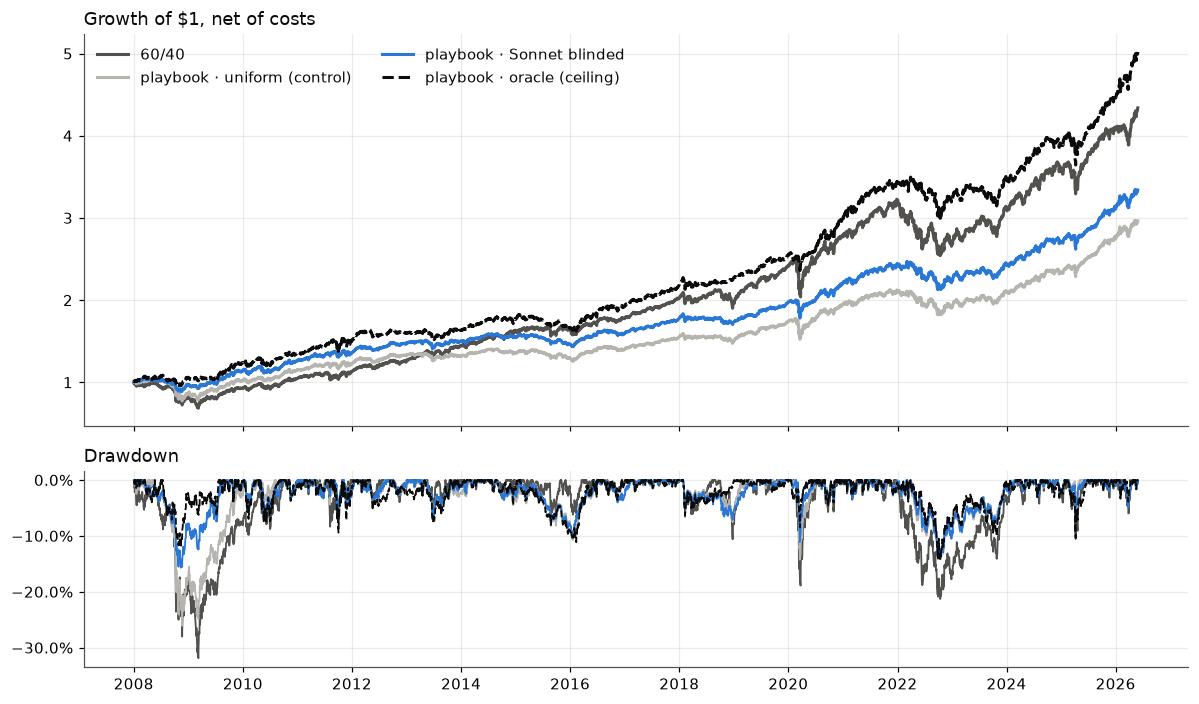

In [4]:
show = [('sixty_forty', '60/40'), ('playbook__uniform', 'playbook · uniform (control)'),
        ('playbook__llm_sonnet_blinded', 'playbook · Sonnet blinded'), ('playbook__oracle', 'playbook · oracle (ceiling)')]
wealth = (1 + daily[[s for s, _ in show]]).cumprod()
fig, (a1, a2) = plt.subplots(2, 1, figsize=(11, 6.5), sharex=True, height_ratios=[2, 1])
COL = {'sixty_forty': '#52514e', 'playbook__uniform': '#b5b4ae', 'playbook__llm_sonnet_blinded': SON, 'playbook__oracle': '#0b0b0b'}
for s, lab in show:
    c, ls = COL[s], ('--' if 'oracle' in s else '-')
    a1.plot(wealth.index, wealth[s], color=c, label=lab, linestyle=ls)
    a2.plot(wealth.index, wealth[s] / wealth[s].cummax() - 1, color=c, linewidth=1.2, linestyle=ls)
a1.set_title('Growth of $1, net of costs', loc='left'); a1.legend(frameon=False, ncol=2, loc='upper left')
a2.set_title('Drawdown', loc='left'); a2.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1))
plt.tight_layout(); plt.show()

**Reading.** **Key finding:** playbooks are lower-risk than 60/40 by construction, so compare risk-adjusted. Driving the playbook with blinded Sonnet gives Sharpe 0.76 and a −16% maximum drawdown (60/40: 0.66, −32%), for a lower return (7% a year against 8%) at two-thirds of the volatility. It sits about 40% of the way from the uniform control (0.61) to the oracle (0.96), and ML GBT on the raw snapshot lands in the same place (0.75).

## 2. Is any of it significant?

Paired comparison on the same months: annualised Sharpe difference on monthly excess returns, moving-block bootstrap (6-month blocks), 95% CI.

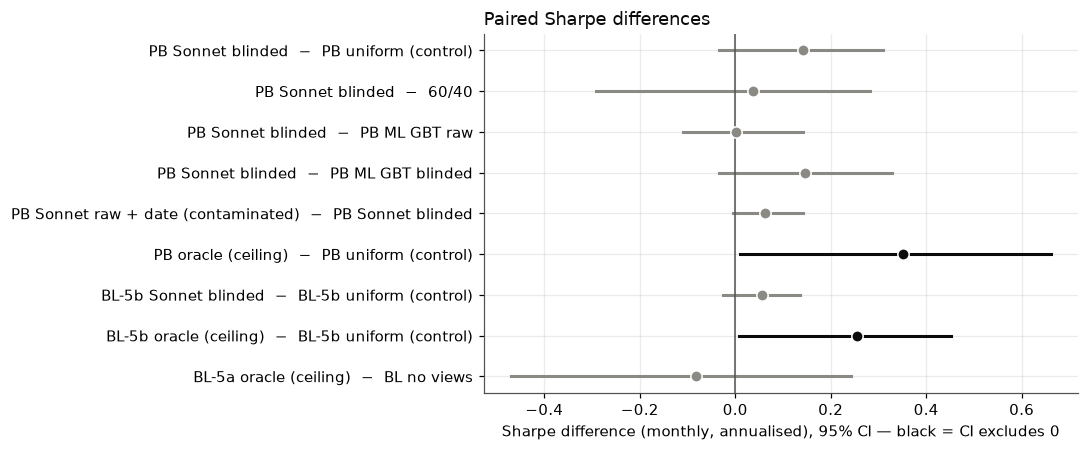

,diff,lo,hi
pair,,,
PB Sonnet blinded − PB uniform (control),0.14,-0.03,0.31
PB Sonnet blinded − 60/40,0.04,-0.29,0.28
PB Sonnet blinded − PB ML GBT raw,0.00,-0.11,0.14
PB Sonnet blinded − PB ML GBT blinded,0.15,-0.03,0.33
PB Sonnet raw + date (contaminated) − PB Sonnet blinded,0.06,-0.01,0.14
PB oracle (ceiling) − PB uniform (control),0.35,0.01,0.66
BL-5b Sonnet blinded − BL-5b uniform (control),0.06,-0.03,0.14
BL-5b oracle (ceiling) − BL-5b uniform (control),0.25,0.01,0.45
BL-5a oracle (ceiling) − BL no views,-0.08,-0.47,0.24


In [5]:
pairs = [('playbook__llm_sonnet_blinded', 'playbook__uniform'), ('playbook__llm_sonnet_blinded', 'sixty_forty'),
         ('playbook__llm_sonnet_blinded', 'playbook__ml_gbt'), ('playbook__llm_sonnet_blinded', 'playbook__ml_gbt_blinded'),
         ('playbook__llm_sonnet_dated', 'playbook__llm_sonnet_blinded'), ('playbook__oracle', 'playbook__uniform'),
         ('bl_playbook__llm_sonnet_blinded', 'bl_playbook__uniform'), ('bl_playbook__oracle', 'bl_playbook__uniform'),
         ('bl_regime__oracle', 'bl_equilibrium')]
def lab(s):
    if '__' not in s: return {'sixty_forty': '60/40', 'bl_equilibrium': 'BL no views'}[s]
    f, k = s.split('__'); return f"{ {'playbook': 'PB', 'bl_playbook': 'BL-5b', 'bl_regime': 'BL-5a'}[f] } {NAMES[k]}"
ci = pd.DataFrame([dict(zip(['diff', 'lo', 'hi'], sharpe_diff_ci(mex[a], mex[b])), pair=f'{lab(a)}  −  {lab(b)}')
                   for a, b in pairs]).set_index('pair')
fig, ax = plt.subplots(figsize=(10, 4.2))
yp = np.arange(len(ci))[::-1]
for y_, (_, r) in zip(yp, ci.iterrows()):
    c = '#0b0b0b' if r.lo > 0 else '#8a8984'
    ax.plot([r.lo, r.hi], [y_, y_], color=c); ax.scatter(r['diff'], y_, s=55, color=c, edgecolor='white', zorder=3)
ax.axvline(0, color=MUTED, linewidth=1); ax.set_yticks(yp, ci.index)
ax.set_xlabel('Sharpe difference (monthly, annualised), 95% CI — black = CI excludes 0')
ax.set_title('Paired Sharpe differences', loc='left'); plt.tight_layout(); plt.show()
fmt(ci, d2=['diff', 'lo', 'hi'])

**Reading.** **Key finding:** only the oracle clears zero, and only just. With about 220 months, Sharpe differences below roughly 0.3 cannot be resolved: blinded Sonnet's +0.14 over the control (CI [−0.03, 0.31]) points the right way but sits inside the noise, as does the +0.06 that telling it the date adds (the money value of memory).

## 3. Black-Litterman 5a: return-based regime views

Views switch on only once 24 labelled months with complete return windows exist (2009-07); before that every 5a strategy is plain BL.

In [6]:
t = family('bl_regime'); t.loc['BL no views (equilibrium)'] = bench.loc['bl_equilibrium']
fmt(t.sort_values('sharpe', ascending=False), **PF)

,ann_return,ann_vol,sharpe,max_drawdown,turnover_per_year
strategy,,,,,
BL no views (equilibrium),7%,10%,0.57,-32%,0.13
climatology,7%,11%,0.54,-32%,0.41
uniform (control),7%,11%,0.53,-32%,0.41
Sonnet blinded,7%,12%,0.52,-32%,1.49
oracle (ceiling),8%,15%,0.51,-32%,2.80
ML logit raw,7%,13%,0.48,-32%,2.15
ML GBT blinded,7%,13%,0.45,-32%,2.38
Sonnet raw + date (contaminated),6%,12%,0.45,-32%,1.29
Sonnet raw (contaminated),6%,12%,0.44,-32%,1.40


**Reading.** **Key finding:** even the oracle does worse than BL without views (Sharpe 0.51 against 0.57). The problem is the mapping, not the forecaster: three-month regime-conditional means of eight assets are noisy, and absolute views on all of them push the long-only optimiser into concentrated bets (volatility rises from about 10% to 15%). Kept as the result of the design fixed in advance.

## 4. Black-Litterman 5b: playbook-implied views (post-hoc)

Declared after 5a, one design only. The views are the equilibrium returns of the probability-weighted playbook, so BL tilts the reference portfolio toward the regime portfolio in proportion to how decisive the forecast is. κ is plotted from 2009-07, when the labelled history used by design 5a starts.

In [7]:
t = family('bl_playbook'); t.loc['BL no views (equilibrium)'] = bench.loc['bl_equilibrium']
fmt(t.sort_values('sharpe', ascending=False), **PF)

,ann_return,ann_vol,sharpe,max_drawdown,turnover_per_year
strategy,,,,,
oracle (ceiling),8%,8%,0.86,-16%,1.17
Sonnet raw + date (contaminated),7%,8%,0.68,-22%,0.30
Sonnet raw (contaminated),7%,9%,0.66,-24%,0.33
ML GBT raw,7%,9%,0.65,-26%,0.74
Sonnet blinded,7%,9%,0.65,-24%,0.36
ML logit raw,7%,9%,0.65,-26%,0.65
ML GBT blinded,6%,9%,0.59,-30%,0.64
ML logit blinded,6%,9%,0.59,-26%,0.72
uniform (control),7%,10%,0.58,-31%,0.13


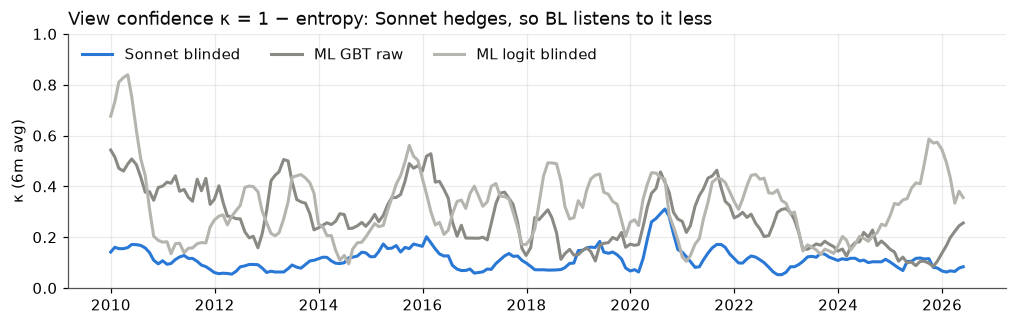

forecaster
llm_sonnet_blinded    0.114
ml_gbt                0.283
ml_logit_blinded      0.327
oracle                1.000
Name: mean κ, dtype: float64

In [8]:
k = views.pivot(index='date', columns='forecaster', values='kappa')
fig, ax = plt.subplots(figsize=(11, 3))
for col, c, lab_ in [('llm_sonnet_blinded', SON, 'Sonnet blinded'), ('ml_gbt', GREY['ml_logit'], 'ML GBT raw'),
                     ('ml_logit_blinded', GREY['ml_gbt'], 'ML logit blinded')]:
    ax.plot(k.index, k[col].rolling(6).mean(), color=c, label=lab_)
ax.set_ylim(0, 1); ax.set_ylabel('κ (6m avg)')
ax.legend(frameon=False, ncol=3, loc='upper left')
ax.set_title('View confidence κ = 1 − entropy: Sonnet hedges, so BL listens to it less', loc='left')
plt.show()
k[['llm_sonnet_blinded', 'ml_gbt', 'ml_logit_blinded', 'oracle']].mean().round(3).rename('mean κ')

**Reading.** The mapping now works: the oracle adds about +0.3 Sharpe over plain BL (0.86 against 0.57). **Key finding:** blinded Sonnet improves on the control (0.65 against 0.58) with a shallower drawdown (−24% against −31%), but its probabilities are diffuse (mean κ 0.11 against about 0.3 for ML), so the tilts are small, and the improvement is not significant (+0.06, CI [−0.03, 0.14]). It also trades about half as much as the ML-driven BL (0.36 against 0.65–0.74 a year).

## 5. Costs

Sharpe at 0, 2.5, 5 and 10 bps on traded notional.

In [9]:
keys = ['sixty_forty', 'bl_equilibrium', 'playbook__uniform', 'playbook__llm_sonnet_blinded', 'playbook__ml_gbt',
        'bl_playbook__llm_sonnet_blinded', 'bl_playbook__ml_gbt', 'playbook__oracle']
s = met[met.strategy.isin(keys)].pivot(index='strategy', columns='cost_bps', values='sharpe').loc[keys]
s.columns = [f'{c:g} bps' for c in s.columns]
s.index = [lab(i) for i in s.index]
s.style.format('{:.2f}')

,0 bps,2.5 bps,5 bps,10 bps
60/40,0.66,0.66,0.65,0.65
BL no views,0.57,0.57,0.57,0.57
PB uniform (control),0.61,0.61,0.61,0.61
PB Sonnet blinded,0.76,0.76,0.75,0.74
PB ML GBT raw,0.76,0.75,0.74,0.72
BL-5b Sonnet blinded,0.65,0.65,0.65,0.64
BL-5b ML GBT raw,0.66,0.65,0.65,0.64
PB oracle (ceiling),0.97,0.96,0.95,0.93


**Reading.** Rankings are stable across cost levels: one-way turnover runs from 0.1 to about 1.8 times a year (oracle highest), so even 10 bps costs at most 0.04 of Sharpe.

## What we can and cannot claim

- **Regime information is worth having if it is mapped simply.** With perfect foresight a playbook reaches Sharpe 0.96 against 0.61 for the uniform control; return-based BL views (5a) throw that away.
- **Blinded Sonnet captures part of it:** Sharpe 0.76 and −16% maximum drawdown (60/40: 0.66, −32%), about 40% of the way from control to ceiling, and no better than ML GBT on the raw snapshot (0.75).
- **Nothing short of the oracle is statistically distinguishable from the control** on about 18 years of monthly data. The allocation results are consistent with nb02's forecast skill; they are not independent proof of it.
- **5b is post-hoc**, labelled as such throughout; its parameters were not tuned.
- **Caveats:** one LLM run per variant here (nb04 measures run-to-run variance); playbooks and reference portfolio set once, ex ante; a single path dominated by 2008, 2020 and 2022.

## Next

nb04 repeats the blinded forecasts with three more model families (GPT, Gemini, GLM) under a pre-registered test, and checks whether blinding holds for them.